# Linear Regression model to Predicting the cost of health insurance by person
### Description of the problem

The important of a health insurance company wants to calculate, based on the physiological data of its customers what will be the premium (cost) to be borne by each of them. To do this, it has assembled a whole team of doctors, and based on data from other companies and a particular study, it has managed to gather a set of data to train a predictive model.



The dataset can be found **https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv**

In this dataset, we have the following variables:

Or download it and add it by hand in your repository. In this dataset, you will find the following variables:

**age**. Age of primary beneficiary (numeric)
**sex**. Gender of the primary beneficiary (categorical)
**bmi**. Body mass index (numeric)
**children**. Number of children/dependents covered by health insurance (numeric)
**smoker**. Is the person a smoker? (categorical)
**region**. Beneficiary's residential area in the U.S.: northeast, southeast, southwest, northwest (categorical)
**charges**. Health insurance premium (numerical)


# EDA

## Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
# Internal code
from analyze_qq_plot import plot_qq_with_analysis
from interpret_distribution_metrics import print_transformation_summary
from save_encoding_rules import save_encoding_rules


# Statistical analysis
from scipy import stats
from scipy.stats import normaltest, shapiro, skew, kurtosis

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Load Dataset

Load the datase and specify the target variable

In [41]:
# Load your dataset
# Example: df = pd.read_csv('../data/raw/your_dataset.csv')
df = pd.read_csv('../data/raw/medical_insurance_cost.csv')

# Define target variable
target_column = 'charges'  # Change this to your target variable

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Target Variable: {target_column}")

Dataset loaded successfully!
Shape: (1338, 7)
Target Variable: charges


## Initial data analysis

In [42]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [43]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [44]:
print("Data Types:")
print(df.dtypes)

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [45]:
print("Stadistic analysis:")
df.describe()

Stadistic analysis:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Missing Values Analysis

In [46]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    display(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Percentage'].plot(kind='barh', color='coral')
    plt.title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")

✓ No missing values found in the dataset!


In [47]:
# Check for duplicate rows
print("="*70)
print("DUPLICATE ROWS DETECTION")
print("="*70)

# Count total duplicates
total_duplicates = df.duplicated().sum()
duplicate_percentage = (total_duplicates / len(df)) * 100

print(f"\nTotal duplicate rows: {total_duplicates}")
print(f"Percentage of duplicates: {duplicate_percentage:.2f}%")

if total_duplicates > 0:
    print(f"\n⚠ {total_duplicates} duplicate rows found!")
    
    # Show duplicate rows
    print("\nDuplicate rows:")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
    display(duplicates_df.head(20))  # Show first 20 duplicates
    
    # Option 1: Keep first occurrence
    print("\n📊 Options for handling duplicates:")
    print("   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')")
    print("   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')")
    print("   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)")
    
else:
    print("\n✓ No duplicate rows found in the dataset!")



DUPLICATE ROWS DETECTION

Total duplicate rows: 1
Percentage of duplicates: 0.07%

⚠ 1 duplicate rows found!

Duplicate rows:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



📊 Options for handling duplicates:
   1. Keep first occurrence: df_clean = df.drop_duplicates(keep='first')
   2. Keep last occurrence:  df_clean = df.drop_duplicates(keep='last')
   3. Remove all duplicates: df_clean = df.drop_duplicates(keep=False)


## Feature Type Identification

In [48]:
# Identify numeric and categorical features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric Features ({len(numeric_features)}):")
print(numeric_features)
print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

Numeric Features (4):
['age', 'bmi', 'children', 'charges']

Categorical Features (3):
['sex', 'smoker', 'region']


## Statistical Summary

In [49]:
# Statistical summary of numeric features
print("Statistical Summary - Numeric Features:")
df[numeric_features].describe()

Statistical Summary - Numeric Features:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [50]:
# Additional statistics: skewness and kurtosis
stats_df = pd.DataFrame({
    'Skewness': df[numeric_features].skew(),
    'Kurtosis': df[numeric_features].kurtosis()
})
print("\nSkewness and Kurtosis:")
display(stats_df)


Skewness and Kurtosis:


,Skewness,Kurtosis
age,0.055673,-1.245088
bmi,0.284047,-0.050732
children,0.938380,0.202454
charges,1.515880,1.606299


#### For Linear Regression, what Skewness and Kurtosis are important:

1. Feature Transformations:

    * High skewness (|skew| > 1) → Consider log, square root, or Box-Cox transformation
    * Helps achieve normality assumption

2. Outlier Detection:

    * High kurtosis suggests potential outliers that might affect your model

3. Model Performance:

    * Normally distributed features often lead to better regression performance
    * Symmetric features are easier for the model to learn

4. Feature Engineering:

    * Highly skewed features might benefit from binning or polynomial features

In [51]:
# Interpret the distribution statistics

print_transformation_summary(df, numeric_features)

TRANSFORMATION RECOMMENDATIONS SUMMARY

✓ Features that are GOOD as-is (2):
   • age
   • bmi

⚠️ Features to CONSIDER transforming (1):
   • children (skew: 0.938) → Consider: sqrt or log transformation

⚠️⚠️ Features that HIGHLY NEED transformation (1):
   • charges (skew: 1.516, kurt: 1.606)
     → Recommended: log or Box-Cox transformation



## Target Variable Analysis

Understanding the target variable is crucial for Linear Regression. We'll check:
- Distribution shape
- Normality (important assumption)
- Presence of outliers

In [52]:
# Target variable statistics
target_data = df[target_column]

print(f"Target Variable: {target_column}")
print("="*60)
print(f"Mean: {target_data.mean():.2f}")
print(f"Median: {target_data.median():.2f}")
print(f"Std Dev: {target_data.std():.2f}")
print(f"Min: {target_data.min():.2f}")
print(f"Max: {target_data.max():.2f}")
print(f"Range: {target_data.max() - target_data.min():.2f}")
print(f"\nSkewness: {target_data.skew():.2f}")
print(f"Kurtosis: {target_data.kurtosis():.2f}")

# Normality test
print("\nNormality Tests:")
_, shapiro_p = shapiro(target_data.dropna())
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("Data appears normally distributed")
else:
    print("Data is NOT normally distributed")
    print("→ Consider log, sqrt, or Box-Cox transformation")

Target Variable: charges
Mean: 13270.42
Median: 9382.03
Std Dev: 12110.01
Min: 1121.87
Max: 63770.43
Range: 62648.55

Skewness: 1.52
Kurtosis: 1.61

Normality Tests:
Shapiro-Wilk p-value: 0.0000
Data is NOT normally distributed
→ Consider log, sqrt, or Box-Cox transformation


Why This Matters for Linear Regression:
Linear Regression assumes that residuals (errors) are normally distributed. While the features don't need to be perfectly normal, having normally distributed data often:

* Improves model performance
* Makes the model more stable
* Satisfies statistical assumptions

### In this case, I might consider to transform the target to log, sqrt or Box-Cox before transformation

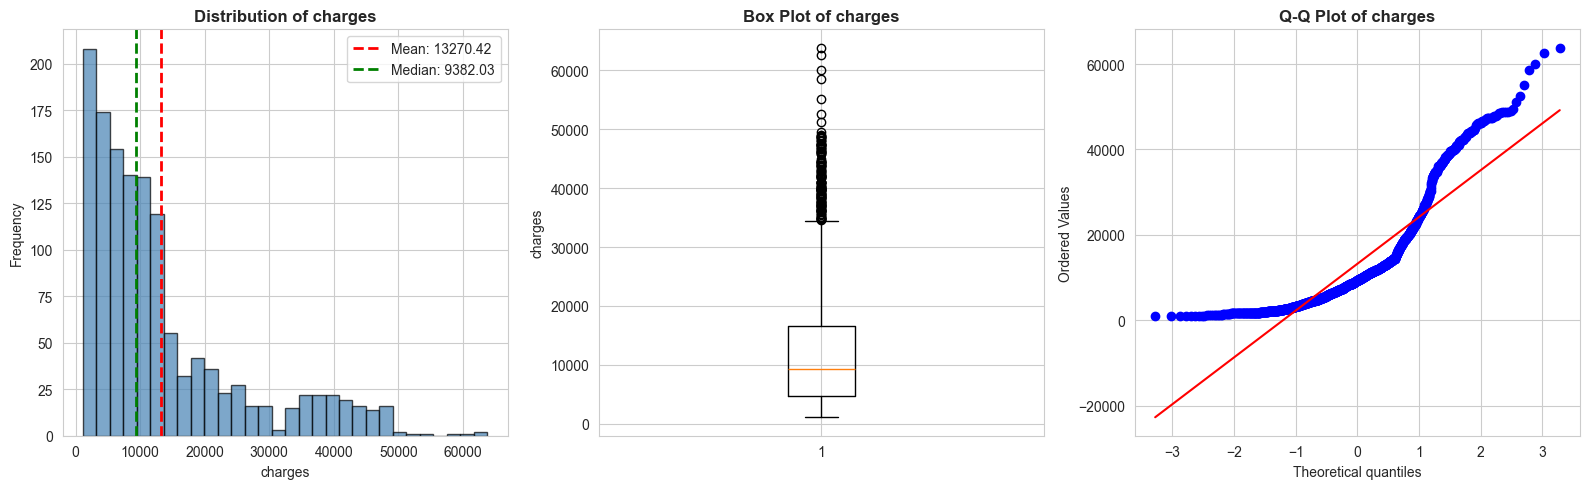

In [53]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(target_data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(target_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {target_data.mean():.2f}')
axes[0].axvline(target_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {target_data.median():.2f}')
axes[0].set_title(f'Distribution of {target_column}', fontsize=12, fontweight='bold')
axes[0].set_xlabel(target_column)
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(target_data.dropna(), vert=True)
axes[1].set_title(f'Box Plot of {target_column}', fontsize=12, fontweight='bold')
axes[1].set_ylabel(target_column)

# Q-Q plot (check normality)
stats.probplot(target_data.dropna(), dist="norm", plot=axes[2])
axes[2].set_title(f'Q-Q Plot of {target_column}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

The target column has oulinders, and the distribution is S-curve (up at right). It might be necessary to do a transformation.

| Pattern    | What It Means | Action |
| -------- | ------- |------- |
| Points on red line  | Normal distribution    | No transformation needed|
| S-curve (up at right)  | 	Right-skewed    | Try: log(x) or sqrt(x)|
| S-curve (down at right)  | Left-skewed    | Try: x² or x³|
| Banana shape  | Heavy tails/outliers   | Check for outliers|
| Points spread away from line  | Heavy tails/outliers    | Consider transformation|


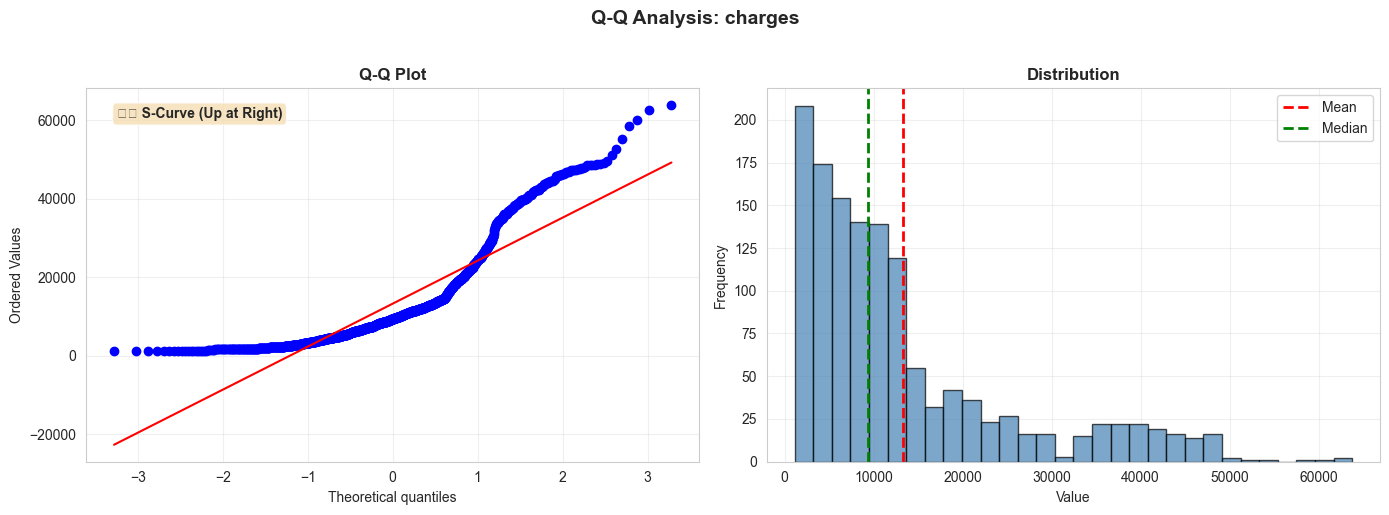

Q-Q PLOT ANALYSIS

⚠️ Pattern Detected: S-Curve (Up at Right)

Interpretation:
  Right-skewed distribution - long tail on right, most values on left

Recommended Action:
  Strongly recommend: log(x) or log(x+1) transformation

Statistics:
  R Squared: 0.8151
  Shapiro P Value: 0.0
  Skewness: 1.514
  Kurtosis: 1.596
  Is Normal: False


In [54]:


# Analyze your target variable
analysis = plot_qq_with_analysis(df[target_column], title=f"Q-Q Analysis: {target_column}")

### Correlation Analysis

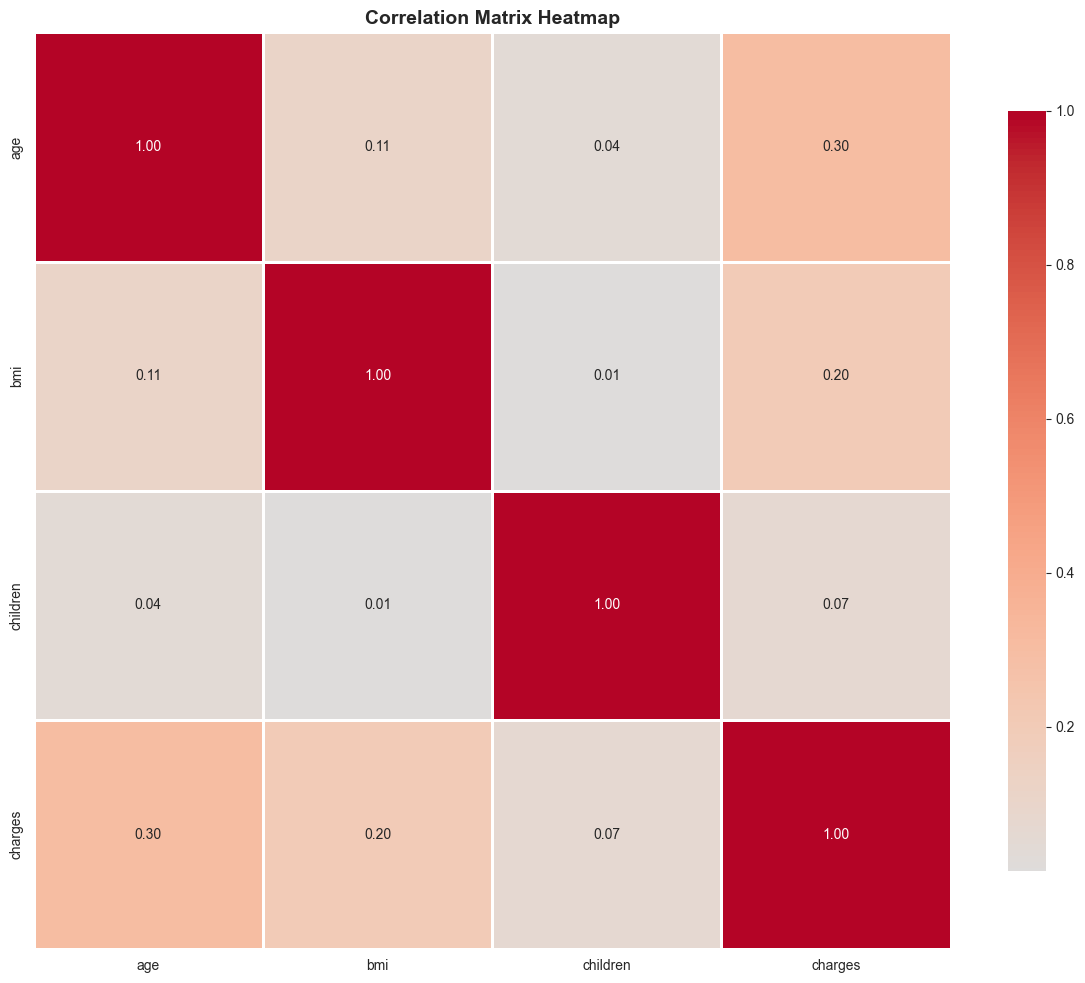


Identify strong correlations (|r| > 0.7)


In [55]:
# Visualize correlation matrix with heatmap
plt.figure(figsize=(12, 10))

correlation_matrix = df[numeric_features].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n" + "="*70)
print("Identify strong correlations (|r| > 0.7)")
print("="*70)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"• {correlation_matrix.columns[i]:20} <-> {correlation_matrix.columns[j]:20} | r = {correlation_matrix.iloc[i, j]:>6.3f}")


### Correlations with target

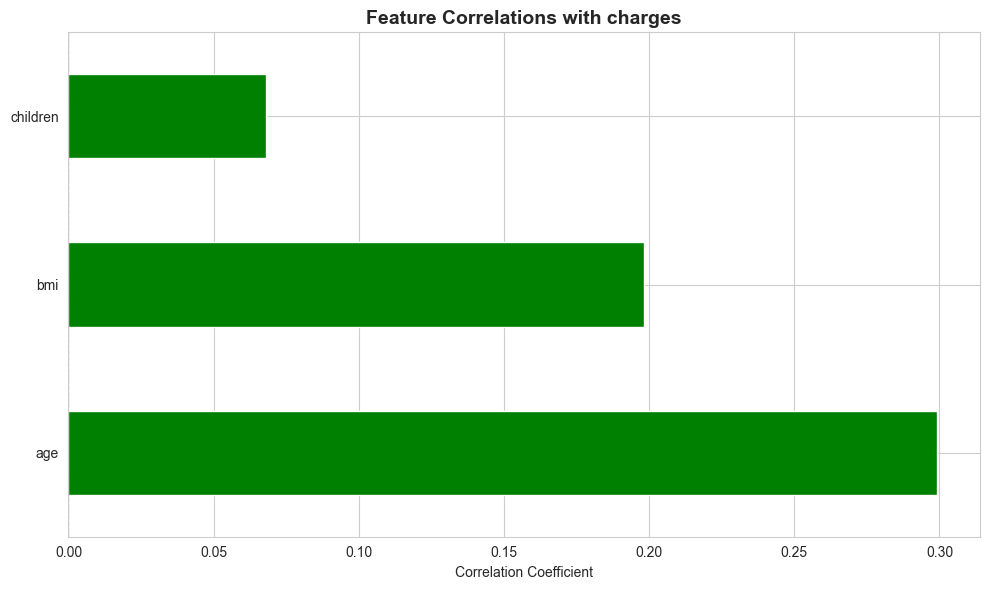

In [56]:
# Bar plot of correlations with target

correlations = correlation_matrix[target_column].sort_values(ascending=False)
target_corr = correlations[correlations.index != target_column]

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title(f'Feature Correlations with {target_column}', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# Outlier Detection
Using the IQR (Interquartile Range)

In [57]:
# Detect outliers using IQR method
outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    if len(outliers) > 0:
        outlier_summary[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

if outlier_summary:
    print("Outliers detected:")
    print("="*60)
    for col, info in outlier_summary.items():
        print(f"\n{col}:")
        print(f"  Count: {info['count']} ({info['percentage']:.2f}%)")
        print(f"  Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")
else:
    print("✓ No outliers detected using IQR method!")

Outliers detected:

bmi:
  Count: 9 (0.67%)
  Bounds: [13.70, 47.29]

charges:
  Count: 139 (10.39%)
  Bounds: [-13109.15, 34489.35]


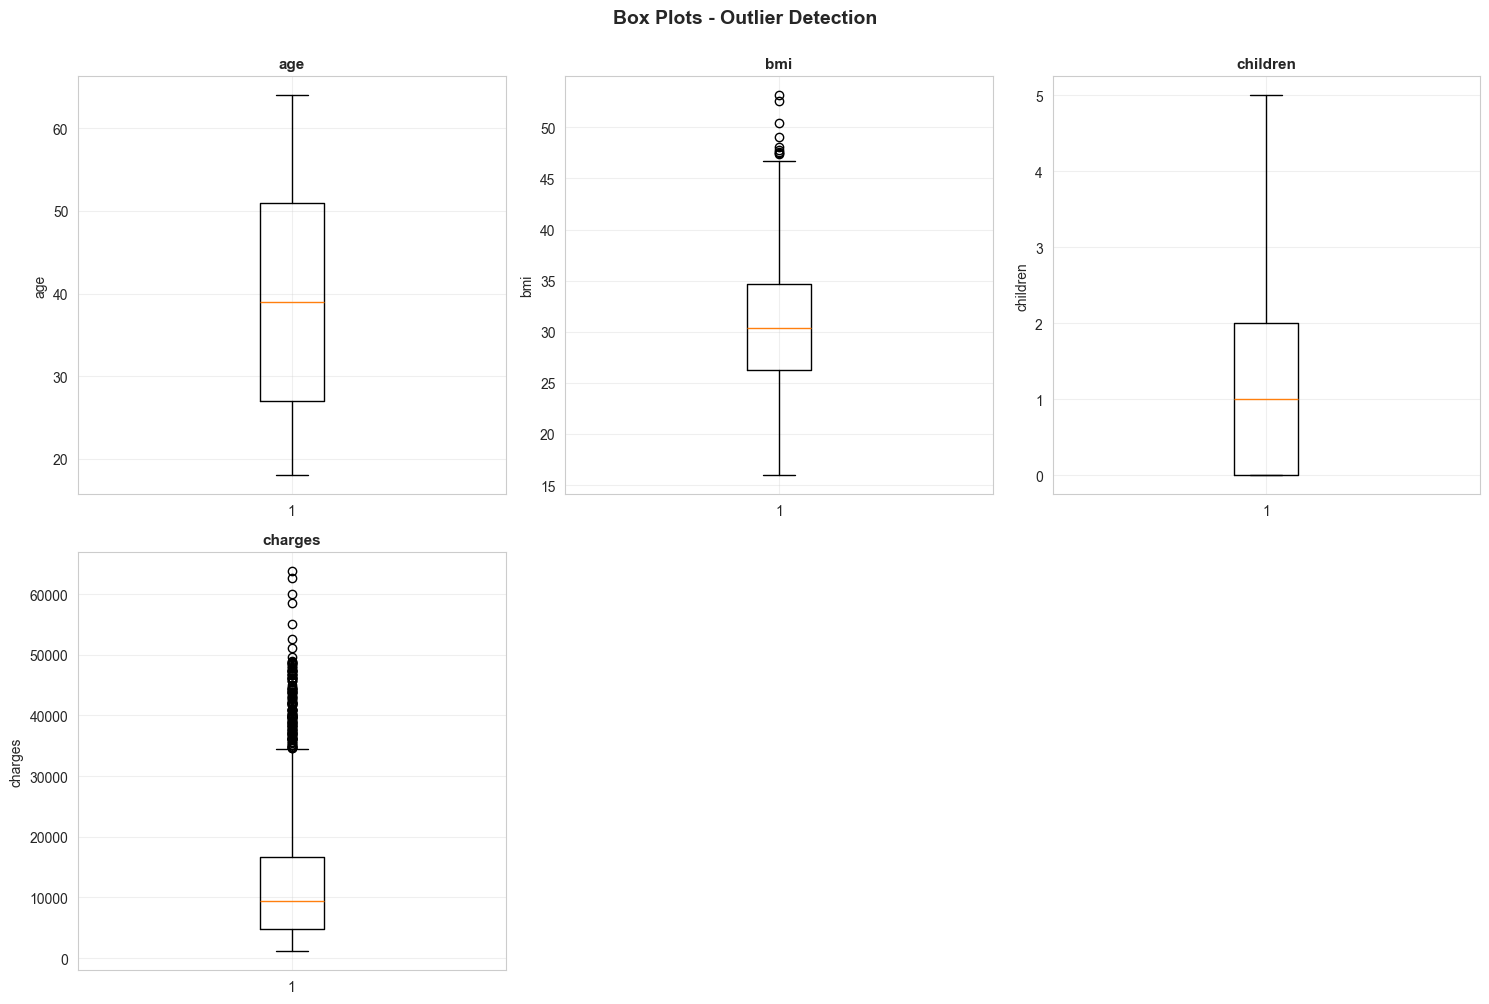

In [58]:
# Visualize outliers with box plots
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Box Plots - Outlier Detection', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Feature Distributions

Identify skewness and potential transformations needed.

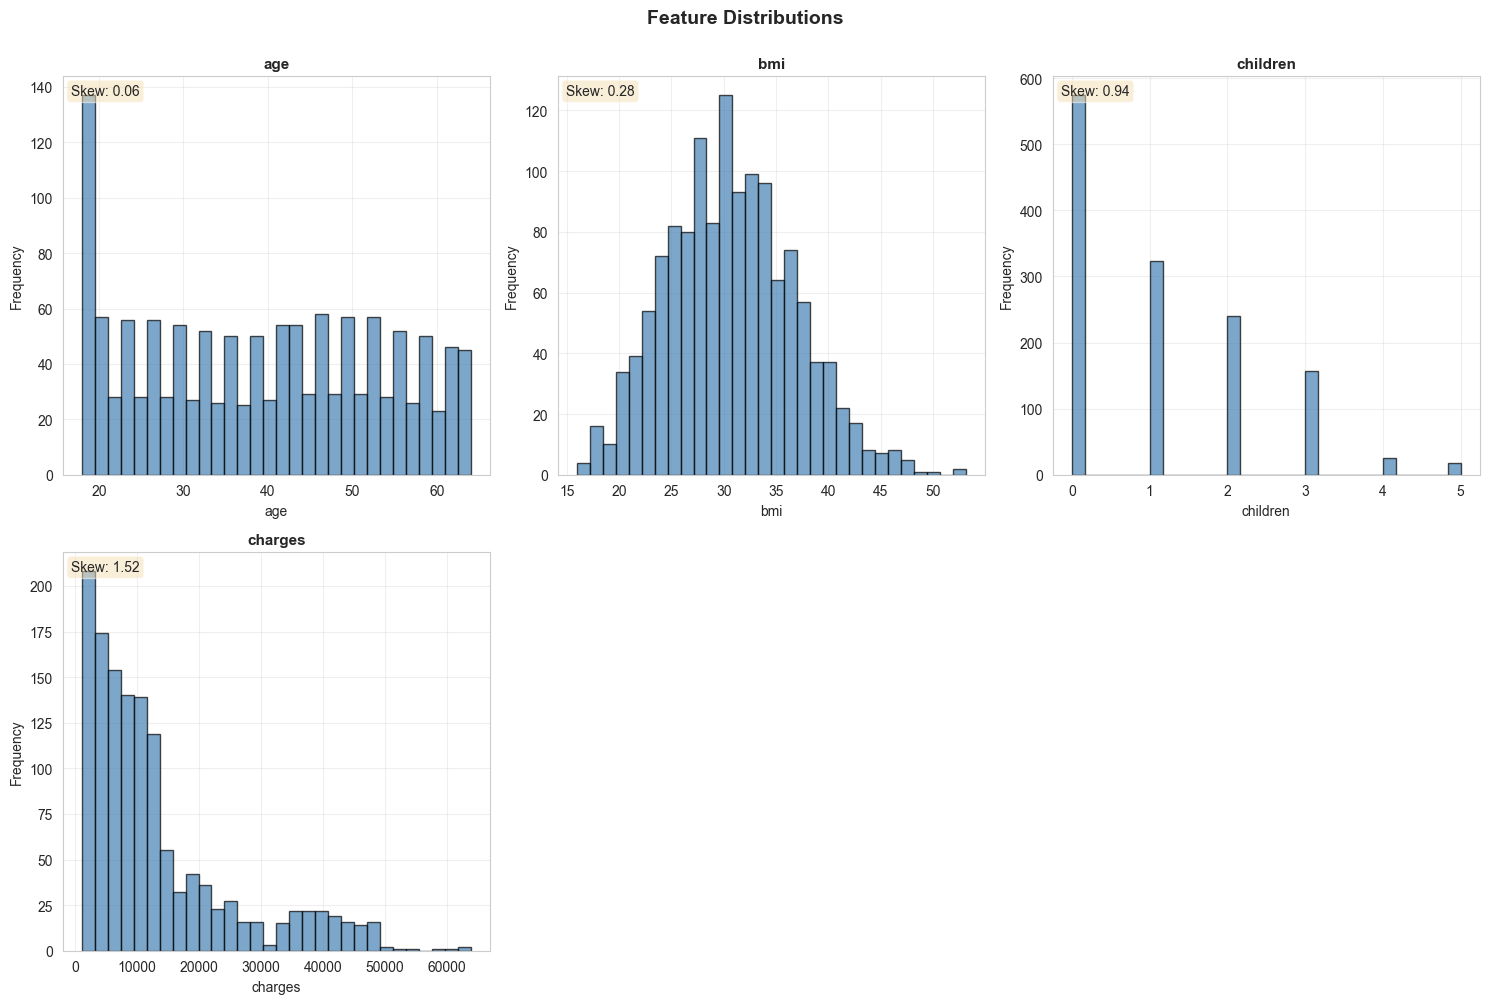

In [59]:
# Histogram for all numeric features
n_features = len(numeric_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Add skewness info
    skewness = df[col].skew()
    axes[idx].text(0.02, 0.98, f'Skew: {skewness:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Feature vs Target Relationships

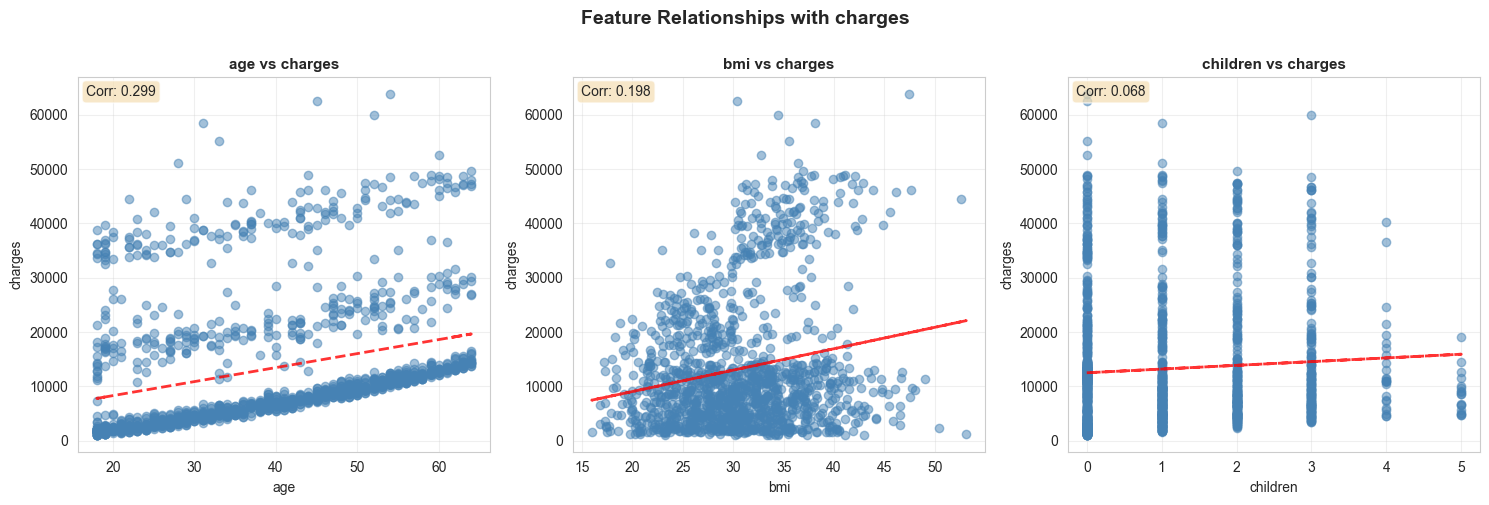

In [60]:
# Scatter plots: Features vs Target
features_to_plot = [f for f in numeric_features if f != target_column]
n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(features_to_plot):
    # Scatter plot
    axes[idx].scatter(df[col], df[target_column], alpha=0.5, color='steelblue')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel(target_column, fontsize=10)
    axes[idx].set_title(f'{col} vs {target_column}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add trend line
    try:
        z = np.polyfit(df[col].dropna(), df[target_column].loc[df[col].dropna().index], 1)
        p = np.poly1d(z)
        axes[idx].plot(df[col], p(df[col]), "r--", alpha=0.8, linewidth=2, label='Trend')
        
        # Add correlation coefficient
        corr = df[col].corr(df[target_column])
        axes[idx].text(0.02, 0.98, f'Corr: {corr:.3f}', 
                       transform=axes[idx].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    except:
        pass

# Hide empty subplots
for idx in range(len(features_to_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Relationships with {target_column}', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Analysisng the Correlations:

1. Age vs Charges (Corr: 0.299)

Pattern Observed:
* Weak to moderate positive correlation
* Clear upward trend line
* Two distinct patterns: Vertical "bands" or clusters at certain age ranges
* Wide spread of values at each age point

Interpretation:
* As age increases, insurance charges tend to increase
* The clustering suggests a hidden categorical variable (likely smoker/non-smoker creating the bands)
* The relationship is not purely linear - there are subgroups

Action:
* Consider interaction terms: age * smoker
* This feature is moderately predictive but needs additional context

2. BMI vs Charges (Corr: 0.198)

Pattern Observed:
* Weak positive correlation
* Very scattered data points
* Trend line is nearly flat
* Three distinct horizontal bands visible

Interpretation:
* BMI alone has weak predictive power for charges
* The horizontal bands strongly suggest stratification by another variable (again, likely smoker status)
* Raw BMI is not a strong linear predictor by itself

Action:
* Create interaction: bmi * smoker (BMI probably matters MORE for smokers)
* Consider binning BMI into categories (underweight, normal, overweight, obese)
3. Children vs Charges (Corr: 0.068)

Pattern Observed:
* Very weak correlation (nearly zero)
* Vertical columns of points (categorical nature - discrete values 0-5)
* Slight upward trend, but minimal
* High variance at each level

Interpretation:
* Number of children has almost no direct relationship with insurance charges
* Each children value shows similar charge distributions
* This feature alone is not predictive

Action:
* Consider dropping this feature or use as categorical
* May only matter in interaction with other variables

Summarie:
- age, it might be used with another variable as smoker
- bmi, it might be used with another variable as smoker
- children, it might be dropped from the dataset, it doesn´t have to much impact in the cost of the insurance

In [61]:
### Categorical Features Analysis


In [62]:
# Categorical features summary
if categorical_features:
    print("Categorical Features Summary:")
    print("="*30)
    for col in categorical_features:
        print(f"\n{col}:")
        print("="*30)
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Value counts:")
        print(df[col].value_counts())
else:
    print("✓ No categorical features in the dataset.")

Categorical Features Summary:

sex:
  Unique values: 2
  Value counts:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
  Unique values: 2
  Value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
  Unique values: 4
  Value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


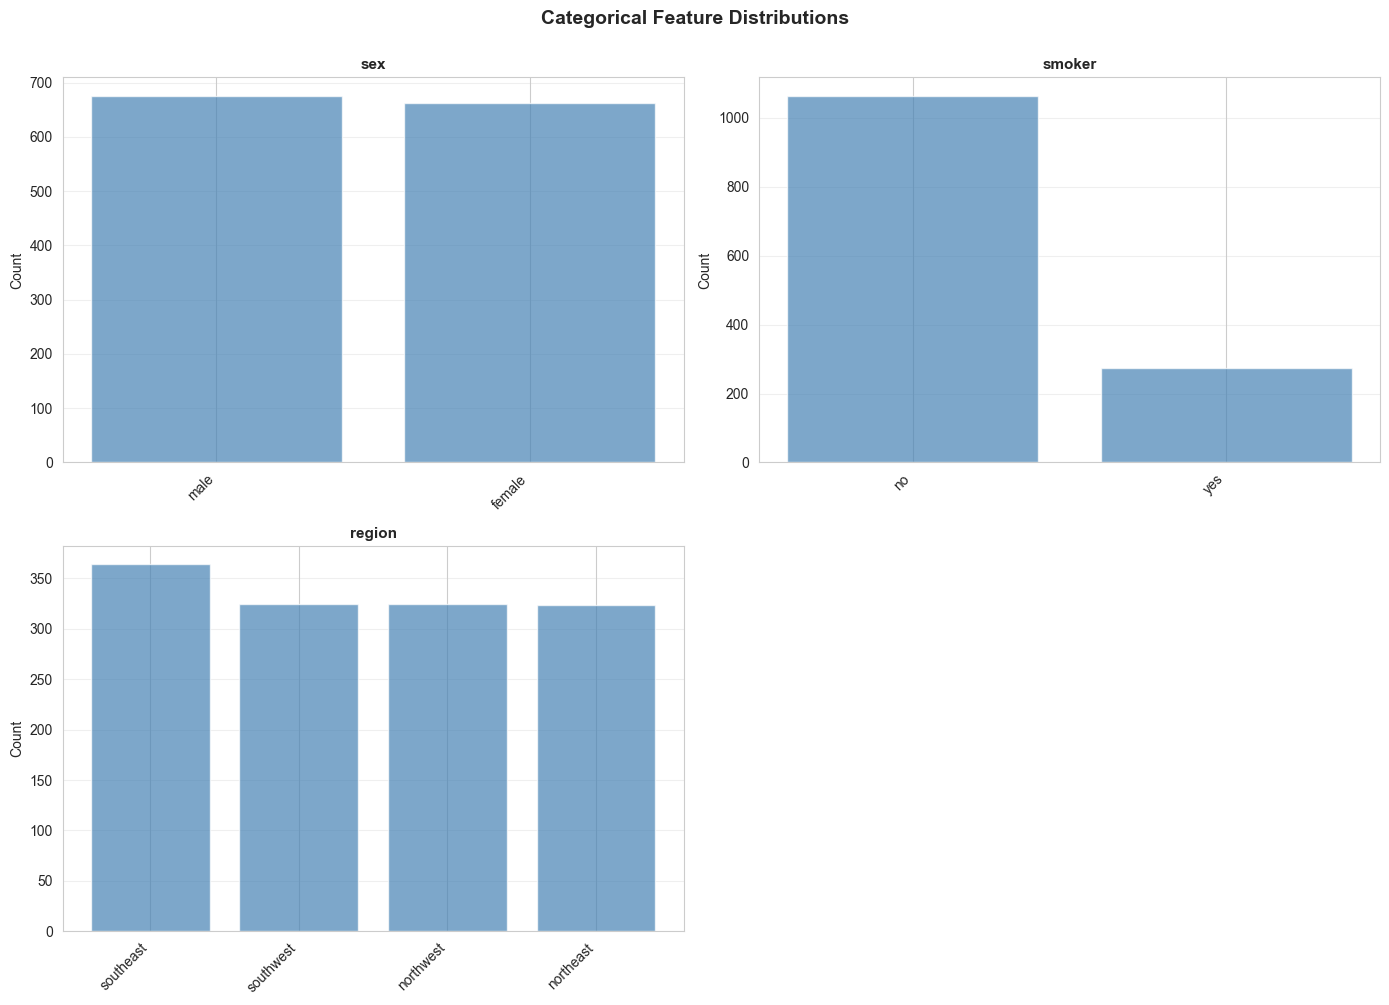

In [63]:
# Visualize categorical features
if categorical_features:
    n_features = len(categorical_features)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(categorical_features):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.7)
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Hide empty subplots
    for idx in range(len(categorical_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

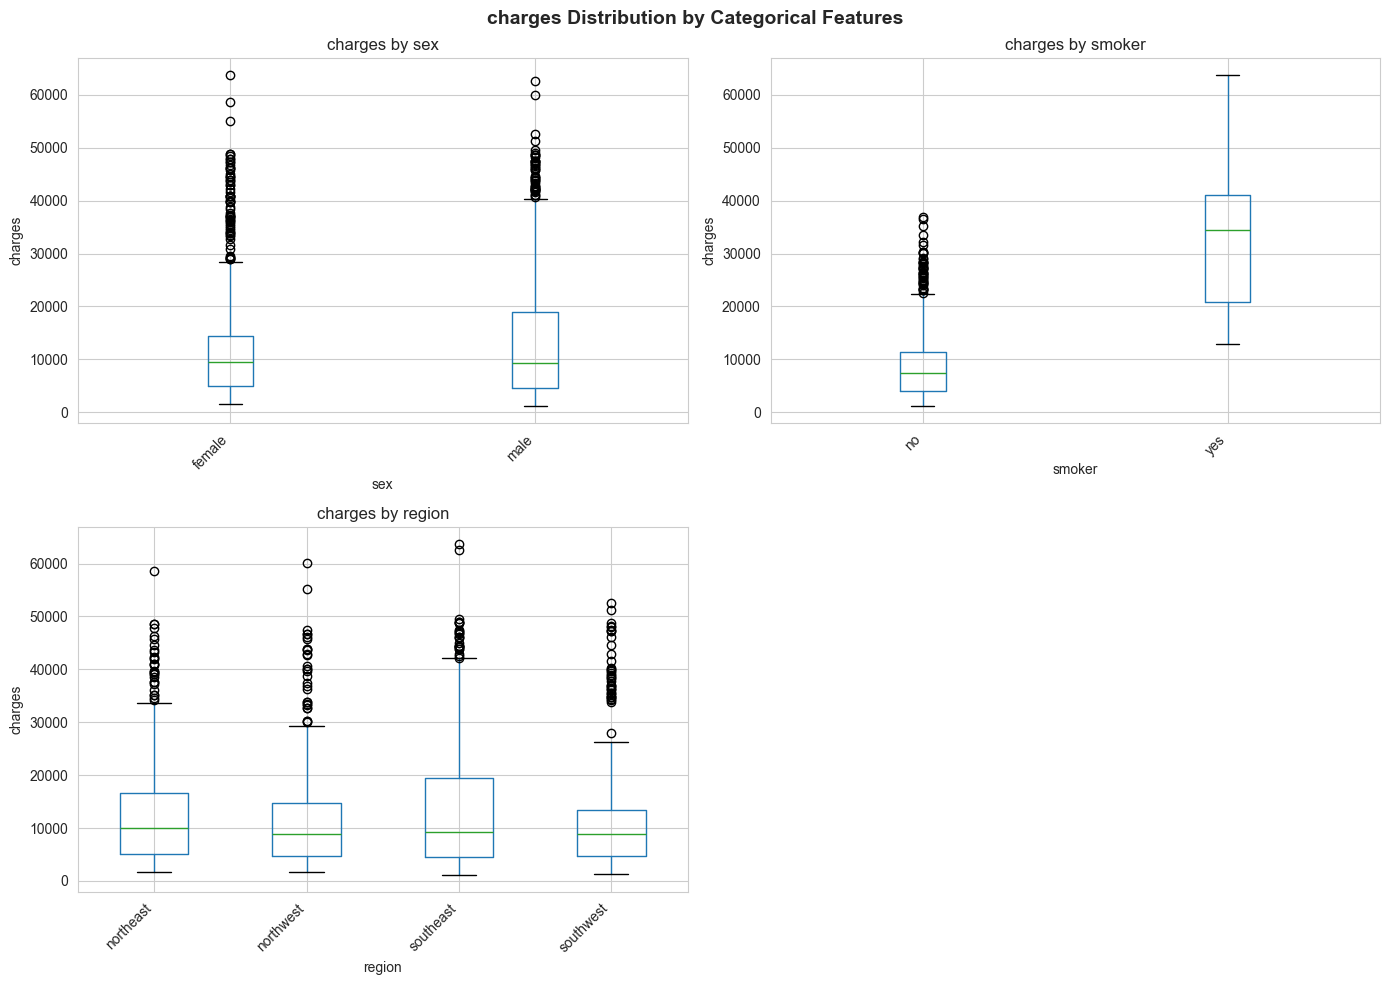

In [64]:
# Categorical features vs target (box plots)
if categorical_features:
    n_features = len(categorical_features)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for idx, col in enumerate(categorical_features):
        df.boxplot(column=target_column, by=col, ax=axes[idx])
        axes[idx].set_title(f'{target_column} by {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(target_column)
        plt.sca(axes[idx])
        plt.xticks(rotation=45, ha='right')
    
    # Hide empty subplots
    for idx in range(len(categorical_features), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'{target_column} Distribution by Categorical Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Pairplot - Relationships Overview

Creating pairplot for: ['age', 'bmi', 'children', 'charges']


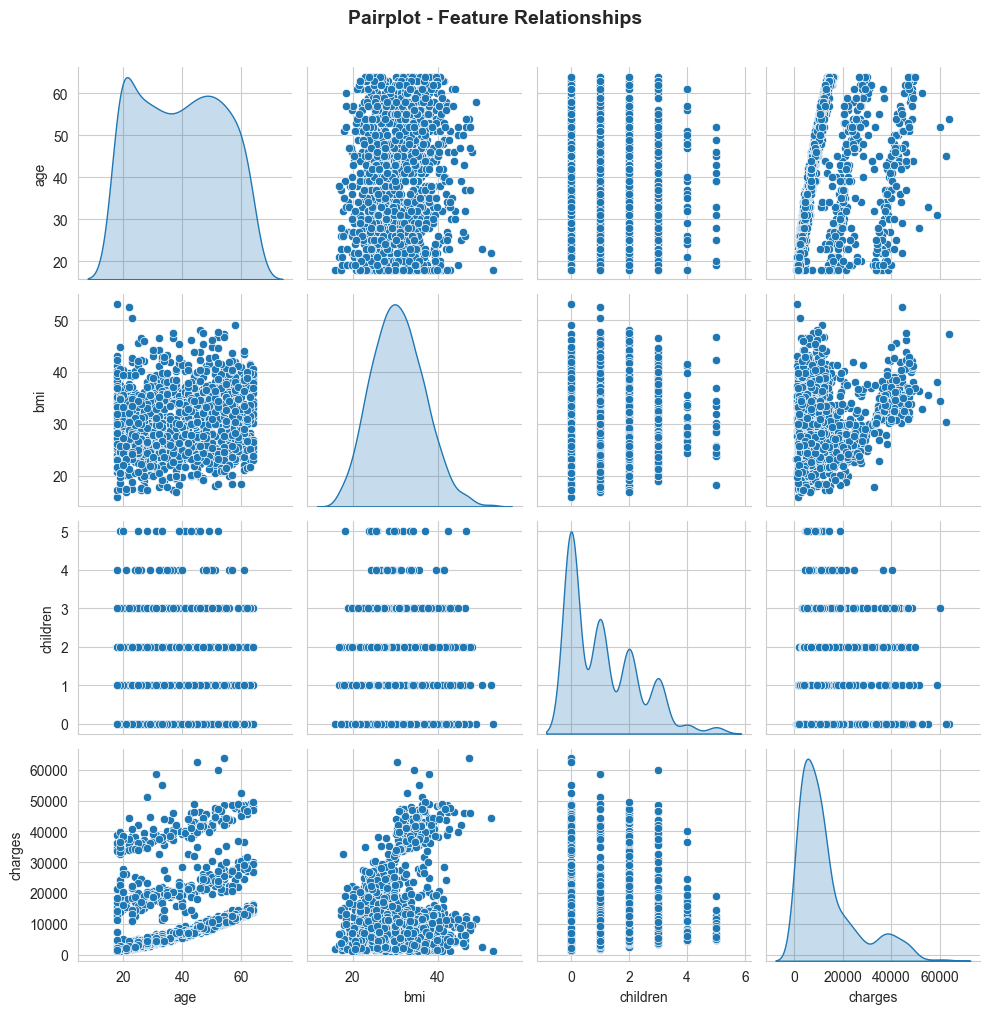

In [65]:
# Pairplot for numeric features (limit to avoid overcrowding)
features_for_pairplot = numeric_features[:6] if len(numeric_features) > 6 else numeric_features

if target_column not in features_for_pairplot:
    features_for_pairplot = [target_column] + [f for f in features_for_pairplot if f != target_column][:5]

print(f"Creating pairplot for: {features_for_pairplot}")
sns.pairplot(df[features_for_pairplot], diag_kind='kde', corner=False)
plt.suptitle('Pairplot - Feature Relationships', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The horizontal stratification in bmi vs charges, age vs charges and children vs charges, detects that maybe there is another categorical variable quite important in the analysis and it can be used with the numerical variables.
This variable might be "smoker". Check the pariplot with smoker variable.

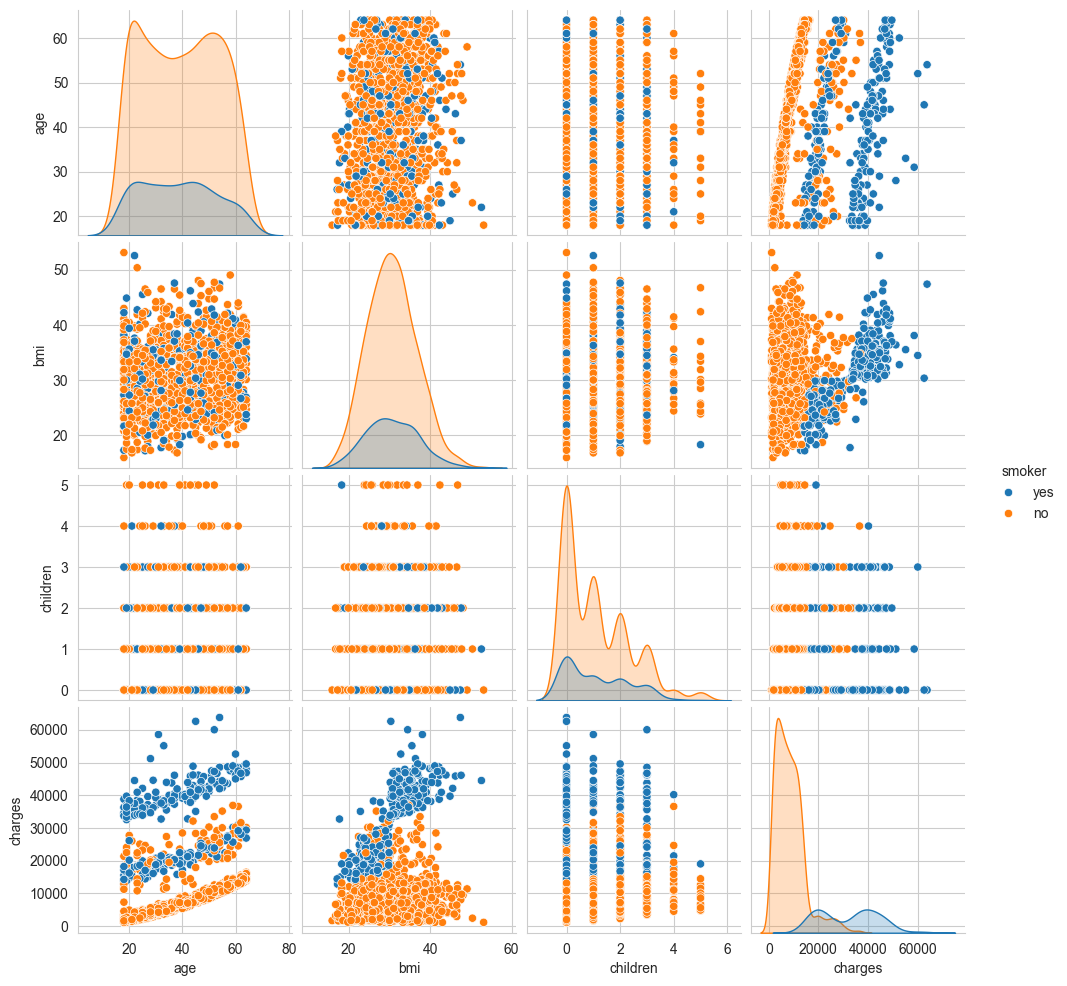

In [66]:
# 1. Verify stratification by plotting with smoker
sns.pairplot(df[['age', 'bmi', 'children', 'smoker', 'charges']], hue='smoker')

# 2. Create interaction features
df['age_smoker'] = df['age'] * (df['smoker'] == 'yes').astype(int)
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)

# 3. Consider dropping children or using as categorical
# df = df.drop('children', axis=1)  # OR
# df['children'] = df['children'].astype('category')

### Conclussions and key insights from the EDA


In [67]:
print("="*80)
print("KEY FINDINGS AND RECOMMENDATIONS FOR LINEAR REGRESSION")
print("="*80)

# 1. Target Variable Normality
_, shapiro_p = shapiro(df[target_column].dropna())
print(f"\n1. Target Variable Normality:")
if shapiro_p > 0.05:
    print(f"   ✓ Target is approximately normally distributed (p={shapiro_p:.4f})")
else:
    print(f"   ⚠ Target is NOT normally distributed (p={shapiro_p:.4f})")
    print(f"   → Consider: log transformation, Box-Cox transformation")

# 2. Strong Correlations
print(f"\n2. Strong Correlations with {target_column}:")
strong_corr = correlations[abs(correlations) > 0.5]
strong_corr = strong_corr[strong_corr.index != target_column]
if len(strong_corr) > 0:
    for feature, corr in strong_corr.items():
        print(f"   {feature}: {corr:.3f}")
else:
    print("   ⚠ No features with strong correlation (|r| > 0.5) found")

# 3. Multicollinearity Check
print(f"\n3. Multicollinearity Check:")
high_collinearity = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_collinearity.append(
                (correlation_matrix.columns[i], 
                 correlation_matrix.columns[j], 
                 correlation_matrix.iloc[i, j])
            )

if high_collinearity:
    print("   ⚠ High correlation detected between features:")
    for feat1, feat2, corr in high_collinearity:
        print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print("   → Consider: removing one feature, PCA, or regularization")
else:
    print("   ✓ No significant multicollinearity detected")

# 4. Outliers
print(f"\n4. Outliers:")
if outlier_summary:
    print("   ⚠ Outliers detected in:")
    for col, info in outlier_summary.items():
        print(f"   {col}: {info['count']} outliers ({info['percentage']:.2f}%)")
    print("   → Consider: removal, transformation, or robust regression")
else:
    print("   ✓ No significant outliers detected")

# 5. Missing Values
print(f"\n5. Missing Values:")
total_missing = df.isnull().sum().sum()
if total_missing > 0:
    print(f"   ⚠ {total_missing} missing values found")
    print("   → Handle before modeling: imputation or removal")
else:
    print("   ✓ No missing values")

# 6. Feature Engineering - Interaction Terms
print(f"\n6. Feature Engineering - Interaction Terms Created:")
print("   Creating interaction features based on EDA insights...")

# Create interaction features
df['age_smoker'] = df['age'] * (df['smoker'] == 'yes').astype(int)
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)

print("   ✓ age_smoker: age * smoker (captures age effect for smokers)")
print("   ✓ bmi_smoker: bmi * smoker (captures BMI effect for smokers)")

# Show correlation of new features with target
if 'age_smoker' in df.columns and 'bmi_smoker' in df.columns:
    age_smoker_corr = df['age_smoker'].corr(df[target_column])
    bmi_smoker_corr = df['bmi_smoker'].corr(df[target_column])
    print(f"\n   Correlation with {target_column}:")
    print(f"   • age_smoker: {age_smoker_corr:.3f}")
    print(f"   • bmi_smoker: {bmi_smoker_corr:.3f}")
    
    if abs(age_smoker_corr) > 0.3 or abs(bmi_smoker_corr) > 0.3:
        print("   → Interaction features show improved correlation!")

# 7. Categorical Variable Encoding
print(f"\n7. Categorical Variable Encoding:")
print("   Preparing categorical features for modeling...")

# One-hot encode categorical variables
categorical_to_encode = ['sex', 'region']  # smoker will be encoded differently
for col in categorical_to_encode:
    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    print(f"   ✓ {col}: One-hot encoded ({len(dummies.columns)} new columns)")

# Binary encode smoker (if not already done)
if df['smoker'].dtype == 'object':
    df['smoker_encoded'] = (df['smoker'] == 'yes').astype(int)
    print(f"   ✓ smoker: Binary encoded (0=no, 1=yes)")

print(f"\n   Final dataset shape: {df.shape}")
print(f"   Ready for modeling with {df.shape[1]} features")

print("\n" + "="*80)
print("✓ EDA COMPLETED - Ready for feature engineering and modeling!")
print("="*80)

KEY FINDINGS AND RECOMMENDATIONS FOR LINEAR REGRESSION

1. Target Variable Normality:
   ⚠ Target is NOT normally distributed (p=0.0000)
   → Consider: log transformation, Box-Cox transformation

2. Strong Correlations with charges:
   ⚠ No features with strong correlation (|r| > 0.5) found

3. Multicollinearity Check:
   ✓ No significant multicollinearity detected

4. Outliers:
   ⚠ Outliers detected in:
   bmi: 9 outliers (0.67%)
   charges: 139 outliers (10.39%)
   → Consider: removal, transformation, or robust regression

5. Missing Values:
   ✓ No missing values

6. Feature Engineering - Interaction Terms Created:
   Creating interaction features based on EDA insights...
   ✓ age_smoker: age * smoker (captures age effect for smokers)
   ✓ bmi_smoker: bmi * smoker (captures BMI effect for smokers)

   Correlation with charges:
   • age_smoker: 0.789
   • bmi_smoker: 0.845
   → Interaction features show improved correlation!

7. Categorical Variable Encoding:
   Preparing categorica

# Data preprocesing

In this notebook the data processing is implemented in two different ways, 
* The Data processing is going to be implement separately
* The Data processing is going to be implment as part the training processing using a Pipeline.


In [68]:
# =============================================================================
# DATA PROCESSING FOR MODELING
# =============================================================================

print("="*80)
print("DATA PREPROCESSING PIPELINE")
print("="*80)

# Step 0: Create a copy of the original dataset
print("\n Step 0: Create backup of original data")
df_original = df.copy()
df_processed = df.copy()
print(f"   ✓ Original data backed up: {df_original.shape}")
print(f"   ✓ Working copy created: {df_processed.shape}")

# =============================================================================
# Step 1: Remove Duplicates
# =============================================================================
print("\n Step 1: Remove duplicate rows")
duplicates_before = df_processed.duplicated().sum()
print(f"   Duplicates found: {duplicates_before}")

if duplicates_before > 0:
    df_processed = df_processed.drop_duplicates(keep='first')
    print(f"   ✓ Removed {duplicates_before} duplicate rows")
    print(f"   New shape: {df_processed.shape}")
else:
    print(f"   ✓ No duplicates found")

# =============================================================================
# Step 2: Remove 'children' column (weak predictor)
# =============================================================================
print("\n  Step 2: Remove weak predictor columns")
if 'children' in df_processed.columns:
    children_corr = df_processed['children'].corr(df_processed[target_column])
    print(f"   'children' correlation with {target_column}: {children_corr:.3f}")
    df_processed = df_processed.drop('children', axis=1)
    print(f"   ✓ Removed 'children' column (weak correlation)")
    print(f"   New shape: {df_processed.shape}")

# =============================================================================
# Step 3: Create Interaction Features (BEFORE encoding)
# =============================================================================
print("\n  Step 3: Create interaction features")

# Create binary smoker indicator for interactions
smoker_binary = (df_processed['smoker'] == 'yes').astype(int)

# Create interaction features
df_processed['age_smoker'] = df_processed['age'] * smoker_binary
df_processed['bmi_smoker'] = df_processed['bmi'] * smoker_binary

print(f"   ✓ Created 'age_smoker' (age × smoker)")
print(f"   ✓ Created 'bmi_smoker' (bmi × smoker)")

# Check correlations
age_smoker_corr = df_processed['age_smoker'].corr(df_processed[target_column])
bmi_smoker_corr = df_processed['bmi_smoker'].corr(df_processed[target_column])
print(f"   age_smoker correlation: {age_smoker_corr:.3f}")
print(f"   bmi_smoker correlation: {bmi_smoker_corr:.3f}")

# =============================================================================
# Step 4: Encode Categorical Variables
# =============================================================================
print("\n Step 4: Encode categorical variables")

# Binary encoding for 'smoker' (yes=1, no=0)
if df_processed['smoker'].dtype == 'object':
    df_processed['smoker_encoded'] = smoker_binary
    print(f"   ✓ smoker: Binary encoded (yes=1, no=0)")

# One-hot encoding for 'sex' (drop_first to avoid multicollinearity)
if 'sex' in df_processed.columns and df_processed['sex'].dtype == 'object':
    sex_dummies = pd.get_dummies(df_processed['sex'], prefix='sex', drop_first=True)
    df_processed = pd.concat([df_processed, sex_dummies], axis=1)
    print(f"   ✓ sex: One-hot encoded ({len(sex_dummies.columns)} column: {list(sex_dummies.columns)})")

# One-hot encoding for 'region' (drop_first to avoid multicollinearity)
if 'region' in df_processed.columns and df_processed['region'].dtype == 'object':
    region_dummies = pd.get_dummies(df_processed['region'], prefix='region', drop_first=True)
    df_processed = pd.concat([df_processed, region_dummies], axis=1)
    print(f"   ✓ region: One-hot encoded ({len(region_dummies.columns)} columns)")
    print(f"      Columns created: {list(region_dummies.columns)}")

print(f"   New shape after encoding: {df_processed.shape}")

# =============================================================================
# Step 4.5: Remove duplicate columns if any exist
# =============================================================================
print("\n Step 4.5: Check and remove duplicate columns")
duplicate_cols_check = df_processed.columns[df_processed.columns.duplicated()].tolist()
if duplicate_cols_check:
    print(f"   ⚠️  Found duplicate columns: {duplicate_cols_check}")
    df_processed = df_processed.loc[:, ~df_processed.columns.duplicated()]
    print(f"   ✓ Removed duplicate columns")
else:
    print(f"   ✓ No duplicate columns found")

print(f"   Shape after duplicate removal: {df_processed.shape}")

# Save enconded rules
# Define transformations that were applied
transformations_applied = {
    "original_target": "charges",
    "transformed_target": "charges_log",
    "transformation": "log1p",
    "formula": "np.log1p(charges)",
    "description": "Natural log transformation to reduce skewness",
    "inverse_transformation": "np.expm1(charges_log)",
    "reason": "Original target was right-skewed (skewness > 1.0)"
}

# Define features that were removed
features_removed = {
    "children": {
        "reason": "Weak correlation with target",
        "correlation_with_target": 0.068,
        "action": "Dropped from dataset"
    }
}

# Call the function
encoding_path = save_encoding_rules(
    df_original=df_original,
    df_processed=df_processed,
    notebook_name='03-linear-regression-reg-demographic-health-data_mio',
    transformations_applied=transformations_applied,
    features_removed=features_removed
)

print(f"\n📄 Encoding rules saved to: {encoding_path}")

# =============================================================================
# Step 5: Log Transformation of Target Variable
# =============================================================================
print("\n Step 5: Transform target variable")

# Store original target
df_processed['charges_original'] = df_processed[target_column].copy()

# Apply log transformation (log(x + 1) to handle any zeros)
df_processed['charges_log'] = np.log1p(df_processed[target_column])

# Compare distributions
print(f"   Original '{target_column}' statistics:")
print(f"      Mean: {df_processed['charges_original'].mean():.2f}")
print(f"      Std: {df_processed['charges_original'].std():.2f}")
print(f"      Skewness: {df_processed['charges_original'].skew():.3f}")

print(f"\n   Log-transformed '{target_column}' statistics:")
print(f"      Mean: {df_processed['charges_log'].mean():.2f}")
print(f"      Std: {df_processed['charges_log'].std():.2f}")
print(f"      Skewness: {df_processed['charges_log'].skew():.3f}")

# Test normality
_, shapiro_p_original = shapiro(df_processed['charges_original'].sample(min(5000, len(df_processed))))
_, shapiro_p_log = shapiro(df_processed['charges_log'].sample(min(5000, len(df_processed))))

print(f"\n   Shapiro-Wilk test:")
print(f"      Original p-value: {shapiro_p_original:.6f} {'✓ Normal' if shapiro_p_original > 0.05 else '✗ Not normal'}")
print(f"      Log-transformed p-value: {shapiro_p_log:.6f} {'✓ Normal' if shapiro_p_log > 0.05 else '✗ Not normal'}")

if shapiro_p_log > shapiro_p_original:
    print(f"   ✓ Log transformation improved normality!")

# Update target column to use log-transformed version
target_column_processed = 'charges_log'

# =============================================================================
# Step 6: Drop Original Categorical Columns (keep encoded versions)
# =============================================================================
print("\n🧹 Step 6: Clean up - remove original categorical columns")

columns_to_drop = ['smoker', 'sex', 'region']
existing_to_drop = [col for col in columns_to_drop if col in df_processed.columns]

if existing_to_drop:
    df_processed = df_processed.drop(existing_to_drop, axis=1)
    print(f"   ✓ Dropped original categorical columns: {existing_to_drop}")
    print(f"   Final shape: {df_processed.shape}")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("PREPROCESSING SUMMARY")
print("="*80)

print(f"\n Original Dataset:")
print(f"   Shape: {df_original.shape}")
print(f"   Columns: {list(df_original.columns)}")

print(f"\n✨ Processed Dataset:")
print(f"   Shape: {df_processed.shape}")
print(f"   Columns: {list(df_processed.columns)}")

print(f"\n Changes Applied:")
print(f"   1. ✓ Removed {duplicates_before} duplicate rows")
print(f"   2. ✓ Dropped 'children' column (weak predictor)")
print(f"   3. ✓ Created interaction features: age_smoker, bmi_smoker")
print(f"   4. ✓ Encoded categorical variables:")
print(f"      • smoker → smoker_encoded (binary)")
print(f"      • sex → sex_male (one-hot, dropped 'female')")
print(f"      • region → region_* (one-hot, dropped 'northeast')")
print(f"   5. ✓ Log-transformed target: {target_column} → charges_log")
print(f"   6. ✓ Removed original categorical columns and duplicates")

print(f"\n Target Variable: {target_column_processed}")
print(f"\n Dataset is ready for modeling!")
print("="*80)

# Display final dataset preview
print("\n Processed Dataset Preview:")
df_processed.head()

DATA PREPROCESSING PIPELINE

 Step 0: Create backup of original data
   ✓ Original data backed up: (1338, 14)
   ✓ Working copy created: (1338, 14)

 Step 1: Remove duplicate rows
   Duplicates found: 1
   ✓ Removed 1 duplicate rows
   New shape: (1337, 14)

  Step 2: Remove weak predictor columns
   'children' correlation with charges: 0.067
   ✓ Removed 'children' column (weak correlation)
   New shape: (1337, 13)

  Step 3: Create interaction features
   ✓ Created 'age_smoker' (age × smoker)
   ✓ Created 'bmi_smoker' (bmi × smoker)
   age_smoker correlation: 0.789
   bmi_smoker correlation: 0.845

 Step 4: Encode categorical variables
   ✓ smoker: Binary encoded (yes=1, no=0)
   ✓ sex: One-hot encoded (1 column: ['sex_male'])
   ✓ region: One-hot encoded (3 columns)
      Columns created: ['region_northwest', 'region_southeast', 'region_southwest']
   New shape after encoding: (1337, 17)

 Step 4.5: Check and remove duplicate columns
   ⚠️  Found duplicate columns: ['sex_male', 'reg

,age,bmi,charges,age_smoker,bmi_smoker,sex_male,region_northwest,region_southeast,region_southwest,smoker_encoded,charges_original,charges_log
0,19,27.900,16884.92400,19,27.9,False,False,False,True,1,16884.92400,9.734236
1,18,33.770,1725.55230,0,0.0,True,False,True,False,0,1725.55230,7.453882
2,28,33.000,4449.46200,0,0.0,True,False,True,False,0,4449.46200,8.400763
3,33,22.705,21984.47061,0,0.0,True,True,False,False,0,21984.47061,9.998137
4,32,28.880,3866.85520,0,0.0,True,True,False,False,0,3866.85520,8.260455


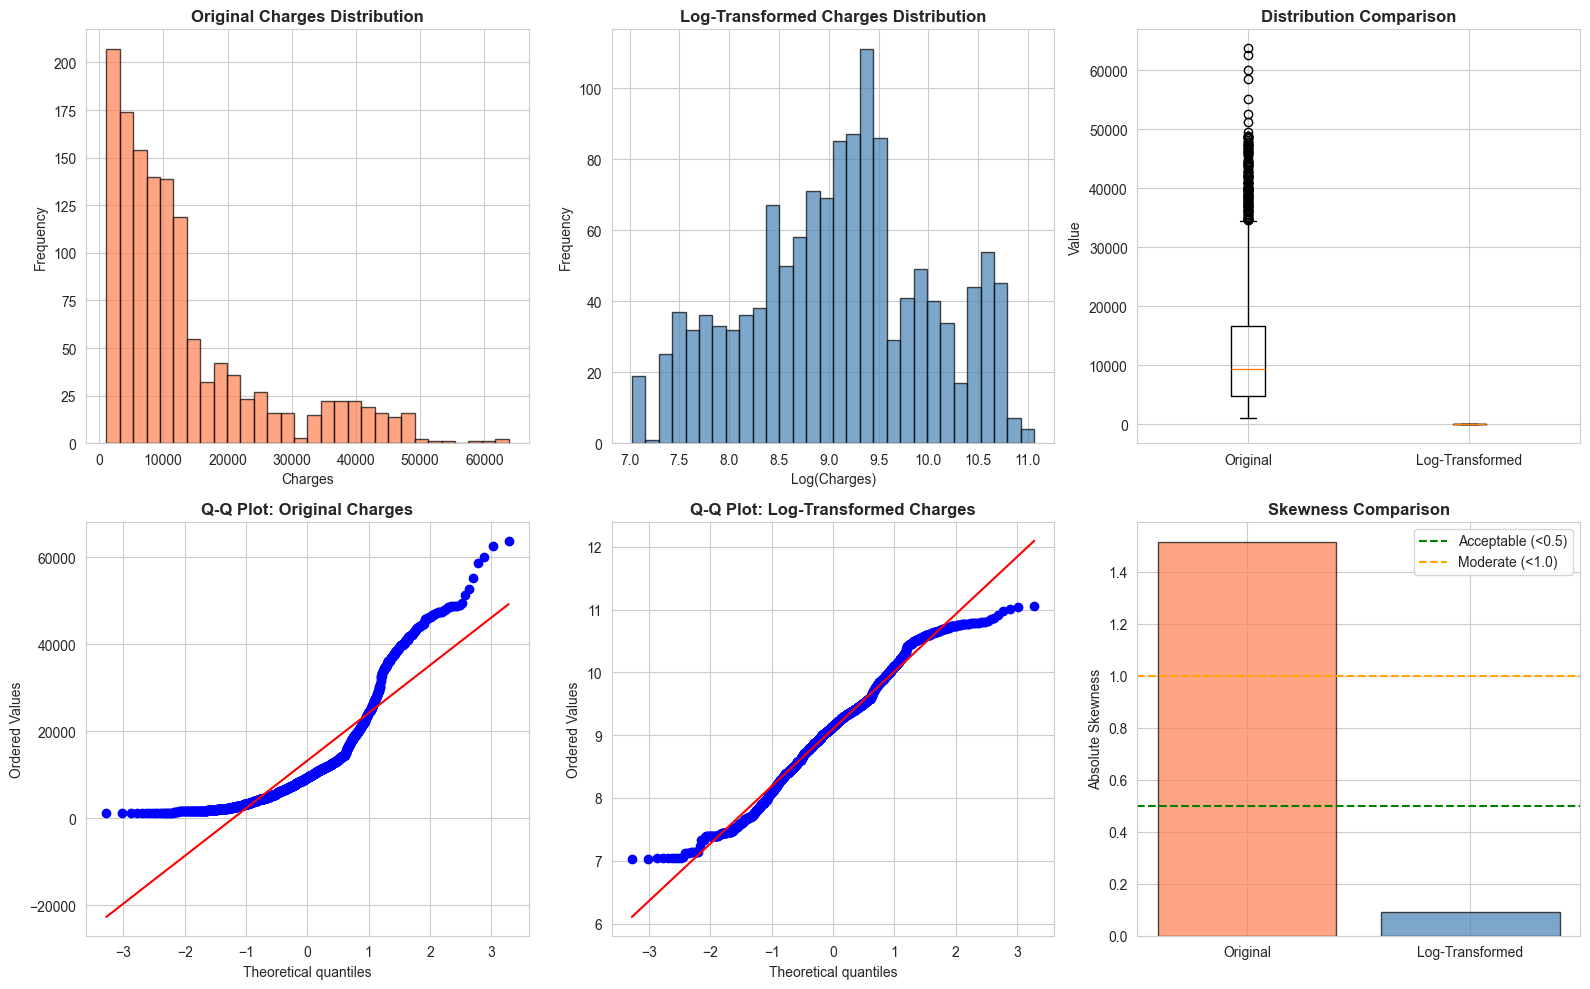

In [69]:
# Visualize the log transformation effect
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Original distribution
axes[0, 0].hist(df_processed['charges_original'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_title('Original Charges Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Charges')
axes[0, 0].set_ylabel('Frequency')

# Log-transformed distribution
axes[0, 1].hist(df_processed['charges_log'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_title('Log-Transformed Charges Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Log(Charges)')
axes[0, 1].set_ylabel('Frequency')

# Box plot comparison
axes[0, 2].boxplot([df_processed['charges_original'], df_processed['charges_log']], 
                    labels=['Original', 'Log-Transformed'])
axes[0, 2].set_title('Distribution Comparison', fontweight='bold')
axes[0, 2].set_ylabel('Value')

# Q-Q plots
stats.probplot(df_processed['charges_original'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Original Charges', fontweight='bold')

stats.probplot(df_processed['charges_log'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log-Transformed Charges', fontweight='bold')

# Skewness comparison
skew_data = pd.DataFrame({
    'Transformation': ['Original', 'Log-Transformed'],
    'Skewness': [df_processed['charges_original'].skew(), df_processed['charges_log'].skew()]
})
axes[1, 2].bar(skew_data['Transformation'], abs(skew_data['Skewness']), 
               color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
axes[1, 2].axhline(y=0.5, color='green', linestyle='--', label='Acceptable (<0.5)')
axes[1, 2].axhline(y=1.0, color='orange', linestyle='--', label='Moderate (<1.0)')
axes[1, 2].set_title('Skewness Comparison', fontweight='bold')
axes[1, 2].set_ylabel('Absolute Skewness')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [70]:
df_processed.columns

Index(['age', 'bmi', 'charges', 'age_smoker', 'bmi_smoker', 'sex_male',
       'region_northwest', 'region_southeast', 'region_southwest',
       'smoker_encoded', 'charges_original', 'charges_log'],
      dtype='object')

# Training the model

In [71]:
# Prepare features and target
# Exclude target variable and original charges from features
X = df_processed.drop(['charges_log', 'charges_original'], axis=1)
y = df_processed['charges_log']

print("Features (X):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {list(X.columns)}")
print(f"\nTarget (y):")
print(f"  Shape: {y.shape}")
print(f"  Name: charges_log (log-transformed)")
print(f"  Range: [{y.min():.2f}, {y.max():.2f}]")

Features (X):
  Shape: (1337, 10)
  Columns: ['age', 'bmi', 'charges', 'age_smoker', 'bmi_smoker', 'sex_male', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_encoded']

Target (y):
  Shape: (1337,)
  Name: charges_log (log-transformed)
  Range: [7.02, 11.06]


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

In [73]:

linear_model = LinearRegression()

print("Training Linear Regression model...")
linear_model.fit(X_train, y_train)
print("Model training completed!")

# Display model coefficients
print("\n" + "="*80)
print("MODEL COEFFICIENTS")
print("="*80)

# Create DataFrame with feature names and coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nIntercept: {linear_model.intercept_:.4f}")
print(f"\nFeature Coefficients (sorted by absolute value):")
print(coef_df.to_string(index=False))
print("="*80)

Training Linear Regression model...
Model training completed!

MODEL COEFFICIENTS

Intercept: 7.3494

Feature Coefficients (sorted by absolute value):
         Feature  Coefficient
  smoker_encoded     2.667848
region_southwest    -0.064621
region_southeast    -0.053268
      bmi_smoker    -0.049392
        sex_male    -0.041792
      age_smoker    -0.032233
             age     0.023237
region_northwest    -0.001456
             bmi    -0.000364
         charges     0.000070


In [74]:
print("\nGenerating predictions...")
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

print("Predictions generated for training and testing sets")
print(f"   Train predictions: {len(y_train_pred)} samples")
print(f"   Test predictions: {len(y_test_pred)} samples")


Generating predictions...
Predictions generated for training and testing sets
   Train predictions: 1069 samples
   Test predictions: 268 samples


In [75]:
# Evaluate on TRAINING set (log scale)
print("\n" + "="*80)
print("TRAINING SET PERFORMANCE (Log Scale)")
print("="*80)

train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Mean Squared Error (MSE):  {train_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {train_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {train_mae:.4f}")
print(f"R² Score: {train_r2:.4f}")


TRAINING SET PERFORMANCE (Log Scale)
Mean Squared Error (MSE):  0.0539
Root Mean Squared Error (RMSE): 0.2321
Mean Absolute Error (MAE): 0.1677
R² Score: 0.9344


In [76]:
# Evaluate on TEST set (log scale)
print("\n" + "="*80)
print("TEST SET PERFORMANCE (Log Scale)")
print("="*80)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE):  {test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"R² Score: {test_r2:.4f}")


TEST SET PERFORMANCE (Log Scale)
Mean Squared Error (MSE):  0.0588
Root Mean Squared Error (RMSE): 0.2425
Mean Absolute Error (MAE): 0.1762
R² Score: 0.9366


In [77]:

# Check for overfitting - check if the model generalizes to unseen data.
print("\n" + "="*80)
print("OVERFITTING CHECK")
print("="*80)

r2_diff = abs(train_r2 - test_r2)
print(f"R² Difference (Train - Test): {r2_diff:.4f}")

if r2_diff < 0.05:
    print("Model generalizes well (minimal overfitting)")
elif r2_diff < 0.10:
    print("Slight overfitting detected")
else:
    print("Significant overfitting detected")


OVERFITTING CHECK
R² Difference (Train - Test): 0.0022
Model generalizes well (minimal overfitting)


In [ ]:
print("MODEL TRAINING AND EVALUATION COMPLETED!")